#  LinkedIn Slop Detector
### Analysing Engagement-Farming Behaviour in LinkedIn Posts

**Dataset:** [LinkedIn Influencers' Data – Kaggle](https://www.kaggle.com/datasets/shreyasajal/linkedin-influencers-data)  
**Goal:** Engineer a Slop Score, run EDA, and build a binary classifier to detect low-substance, high-reach posts.

---
**Sections:**
1. Setup & Data Load
2. Data Cleaning
3. Feature Engineering (Slop Features)
4. Slop Score Calculation
5. Exploratory Data Analysis
6. ML Classification (Slop vs Not Slop)
7. Insights & Conclusion

## 1. Setup & Data Load

In [26]:
import subprocess, sys

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'plotly', 'textblob', 'vaderSentiment',
    'textstat', 'wordcloud', 'scikit-learn', 'nltk'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All dependencies installed.')

✅ All dependencies installed.


In [27]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import textstat

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Settings
pd.set_option('display.max_colwidth', 200)
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Libraries loaded.')

✅ Libraries loaded.


In [28]:
import pandas as pd

# We now know this is secretly a zip file, so we tell Pandas to unzip it on the fly!
df = pd.read_csv('linkedin_data.csv', compression='zip')   

print(f'Shape: {df.shape}')
df.head(3)

Shape: (34012, 19)


,Unnamed: 0,name,headline,location,followers,connections,about,time_spent,content,content_links,media_type,media_url,num_hashtags,hashtag_followers,hashtags,reactions,comments,views,votes
0,0,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone a light on the mismatch between employers seeking qualified staff yet the hordes of people who remain unemployed. Nicks advocated for and created sol...,1 day ago,"Robert Lerman writes that achieving a healthy future of work requires employees to build skills that help them attain productive and rewarding careers. He notes - ""one of the most cost-effective ...","[['https://www.linkedin.com/in/ACoAAACy1HkBviRGLfLG__Jk8FRH2JY2rGg3nTU', 'Robert Lerman'], ['https://www.linkedin.com/feed/hashtag/?keywords=workbasedlearning&highlightedUpdateUrns=urn%3Ali%3Aacti...",article,['https://www.urban.org/urban-wire/its-time-modernize-american-apprenticeship-system'],4,0,"[['#workbasedlearning', 'https://www.linkedin.com/feed/hashtag/?keywords=workbasedlearning&highlightedUpdateUrns=urn%3Ali%3Aactivity%3A6765387069389967360'], ['#USA', 'https://www.linkedin.com/fee...",12,1,NaN,NaN
1,1,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone a light on the mismatch between employers seeking qualified staff yet the hordes of people who remain unemployed. Nicks advocated for and created sol...,1 week ago,"National disability advocate Sara Hart Weir, MS shares how Congress passed the ABLE act","[['https://www.linkedin.com/in/ACoAAAHsfJgBb7_L5hYnTxpQBaYBWWz9Sq_agyk', 'Sara Hart Weir, MS']]",NaN,[],0,0,[],11,0,NaN,NaN
2,2,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone a light on the mismatch between employers seeking qualified staff yet the hordes of people who remain unemployed. Nicks advocated for and created sol...,2 months ago,NaN,[],NaN,[],0,0,[],15,0,NaN,NaN


## 2. Data Cleaning

In [29]:
# Overview
print('=== Column Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Column Types ===
Unnamed: 0             int64
name                     str
headline                 str
location                 str
followers            float64
connections              str
about                    str
time_spent               str
content                  str
content_links            str
media_type               str
media_url                str
num_hashtags           int64
hashtag_followers      int64
hashtags                 str
reactions              int64
comments               int64
views                float64
votes                 object
dtype: object

=== Missing Values ===
Unnamed: 0               0
name                     0
headline                 0
location              2272
followers               42
connections           8299
about                    0
time_spent               1
content               2016
content_links            0
media_type            7233
media_url                0
num_hashtags             0
hashtag_followers        0
hashtags    

In [30]:
# Standardise column names to lowercase + underscores
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

# The Kaggle dataset uses these column names — adjust if yours differ:
# 'content', 'reactions', 'comments', 'followers', 'name', 'media_type'
# Rename for consistency
rename_map = {
    'post_content': 'content',
    'no_reactions': 'reactions',
    'no_comments': 'comments',
    'no_followers': 'followers',
    'author': 'name'
}
df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

# Drop rows with missing content
df.dropna(subset=['content'], inplace=True)

# Fill numeric NaNs with 0
for col in ['reactions', 'comments', 'followers']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Clean content text
df['content'] = df['content'].astype(str).str.strip()

print(f'✅ Cleaned dataset: {df.shape}')
df.head(2)

✅ Cleaned dataset: (31996, 19)


,unnamed:_0,name,headline,location,followers,connections,about,time_spent,content,content_links,media_type,media_url,num_hashtags,hashtag_followers,hashtags,reactions,comments,views,votes
0,0,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone a light on the mismatch between employers seeking qualified staff yet the hordes of people who remain unemployed. Nicks advocated for and created sol...,1 day ago,"Robert Lerman writes that achieving a healthy future of work requires employees to build skills that help them attain productive and rewarding careers. He notes - ""one of the most cost-effective ...","[['https://www.linkedin.com/in/ACoAAACy1HkBviRGLfLG__Jk8FRH2JY2rGg3nTU', 'Robert Lerman'], ['https://www.linkedin.com/feed/hashtag/?keywords=workbasedlearning&highlightedUpdateUrns=urn%3Ali%3Aacti...",article,['https://www.urban.org/urban-wire/its-time-modernize-american-apprenticeship-system'],4,0,"[['#workbasedlearning', 'https://www.linkedin.com/feed/hashtag/?keywords=workbasedlearning&highlightedUpdateUrns=urn%3Ali%3Aactivity%3A6765387069389967360'], ['#USA', 'https://www.linkedin.com/fee...",12,1,NaN,NaN
1,1,Nicholas Wyman,CEO IWSI Group,NaN,6484.0,500+,Nicholas Wyman for the past 25 years has shone a light on the mismatch between employers seeking qualified staff yet the hordes of people who remain unemployed. Nicks advocated for and created sol...,1 week ago,"National disability advocate Sara Hart Weir, MS shares how Congress passed the ABLE act","[['https://www.linkedin.com/in/ACoAAAHsfJgBb7_L5hYnTxpQBaYBWWz9Sq_agyk', 'Sara Hart Weir, MS']]",NaN,[],0,0,[],11,0,NaN,NaN


## 3. Feature Engineering — Slop Features

> Each feature below captures one behavioural pattern of engagement-farming or low-substance posting.

In [31]:
# -------------------------------------------------------
# HELPER: Extract emojis from text
# -------------------------------------------------------
import unicodedata

def count_emojis(text):
    return sum(1 for char in str(text) if unicodedata.category(char) in ('So', 'Sm'))

# -------------------------------------------------------
# ENGAGEMENT BAIT — Call-To-Action phrases
# -------------------------------------------------------
CTA_PATTERNS = [
    r'\bcomment\b', r'\bshare\b', r'\blike this\b', r'\brepost\b',
    r'\btag someone\b', r'\btag a friend\b', r'\bdrop a\b',
    r'\bwhat do you think\b', r'\bwould you agree\b', r'\bdo you agree\b',
    r'\blet me know\b', r'\bsay yes\b', r'\bvote\b', r'\bpoll\b',
    r'\bfollow me\b', r'\bfollow for\b', r'\bjoin me\b',
    r'\btype yes\b', r'\btype 1\b', r'\btype agree\b'
]

def count_cta(text):
    text_lower = str(text).lower()
    return sum(1 for p in CTA_PATTERNS if re.search(p, text_lower))

# -------------------------------------------------------
# HUMBLEBRAG — first-person narrative + success keywords
# -------------------------------------------------------
HUMBLEBRAG_PATTERNS = [
    r"\bi (was|got|have been|am) (rejected|denied|fired|laid off|failed)",
    r"\b(rejected|failed|struggled).*?(now|today|finally)",
    r"\b(dream company|dream job|dream offer)",
    r"\b(humbled|blessed|grateful) to (announce|share|join)",
    r"\b(excited|thrilled|proud) to (announce|share|join|start)",
    r"\b(6 figures|6-figure|multiple offers|offer from)",
    r"\b(imposter syndrome|never thought|didn.t expect)",
]

def count_humblebrag(text):
    text_lower = str(text).lower()
    return sum(1 for p in HUMBLEBRAG_PATTERNS if re.search(p, text_lower))

# -------------------------------------------------------
# VAGUE INSPIRATION — filler motivational phrases
# -------------------------------------------------------
VAGUE_INSPIRATION = [
    r'\bhard work pays off\b', r'\bnever give up\b', r'\bbelieve in yourself\b',
    r'\bdream big\b', r'\bstay consistent\b', r'\bthe journey\b',
    r'\bmindset\b', r'\bgrowth mindset\b', r'\boutside (your|the) comfort zone\b',
    r'\bleverage\b', r'\bsynergy\b', r'\bthought leader\b',
    r'\bvalue add\b', r'\bgame.changer\b', r'\bnext level\b',
    r'\bwinning mindset\b', r'\bserve others\b', r'\bpurpose.driven\b'
]

def count_vague_inspiration(text):
    text_lower = str(text).lower()
    return sum(1 for p in VAGUE_INSPIRATION if re.search(p, text_lower))

print('✅ Feature helpers defined.')

✅ Feature helpers defined.


In [32]:
# -------------------------------------------------------
# APPLY ALL FEATURES
# -------------------------------------------------------

vader = SentimentIntensityAnalyzer()

print('⏳ Engineering features... (may take ~1 min for 34K rows)')

# --- Structural features ---
df['char_count']         = df['content'].str.len()
df['word_count']         = df['content'].str.split().str.len()
df['sentence_count']     = df['content'].apply(lambda x: len(re.split(r'[.!?]+', str(x))))
df['line_count']         = df['content'].str.count('\n') + 1

# --- Punctuation / formatting features ---
df['exclamation_count']  = df['content'].str.count('!')
df['question_count']     = df['content'].str.count(r'\?')
df['caps_ratio']         = df['content'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)
df['emoji_count']        = df['content'].apply(count_emojis)
df['emoji_density']      = df['emoji_count'] / df['word_count'].replace(0, 1)

# --- Hashtags & mentions ---
df['hashtag_count']      = df['content'].str.count(r'#\w+')
df['mention_count']      = df['content'].str.count(r'@\w+')

# --- Slop-specific pattern counts ---
df['cta_count']          = df['content'].apply(count_cta)
df['humblebrag_count']   = df['content'].apply(count_humblebrag)
df['vague_insp_count']   = df['content'].apply(count_vague_inspiration)

# --- Pronoun usage (me-centric) ---
df['i_pronoun_count']    = df['content'].str.lower().str.count(r'\b(i|me|my|myself)\b')
df['i_pronoun_ratio']    = df['i_pronoun_count'] / df['word_count'].replace(0, 1)

# --- NLP: Sentiment (VADER) ---
vader_scores = df['content'].apply(lambda x: vader.polarity_scores(str(x)))
df['vader_pos']  = vader_scores.apply(lambda s: s['pos'])
df['vader_neg']  = vader_scores.apply(lambda s: s['neg'])
df['vader_compound'] = vader_scores.apply(lambda s: s['compound'])

# Extreme positivity = slop signal
df['extreme_positivity'] = (df['vader_compound'] > 0.7).astype(int)

# --- Readability (low Flesch = more complex; high = very simple = slop) ---
df['flesch_reading_ease'] = df['content'].apply(
    lambda x: textstat.flesch_reading_ease(str(x))
)

# --- Engagement metrics ---
if 'followers' in df.columns and df['followers'].max() > 0:
    df['engagement_rate'] = (df['reactions'] + df['comments']) / df['followers'].replace(0, 1)
else:
    df['engagement_rate'] = df['reactions'] + df['comments']

# Reaction-to-comment ratio (slop gets lots of reactions, few real comments)
df['reaction_to_comment_ratio'] = df['reactions'] / df['comments'].replace(0, 1)

print('✅ Feature engineering complete!')
print(f'Total features: {df.shape[1]}')
df[['content', 'cta_count', 'humblebrag_count', 'emoji_density', 
    'vague_insp_count', 'vader_compound', 'engagement_rate']].head(5)

⏳ Engineering features... (may take ~1 min for 34K rows)
✅ Feature engineering complete!
Total features: 42


,content,cta_count,humblebrag_count,emoji_density,vague_insp_count,vader_compound,engagement_rate
0,"Robert Lerman writes that achieving a healthy future of work requires employees to build skills that help them attain productive and rewarding careers. He notes - ""one of the most cost-effective ...",0,0,0.0,0,0.9583,0.002005
1,"National disability advocate Sara Hart Weir, MS shares how Congress passed the ABLE act",0,0,0.0,0,0.2960,0.001696
3,Exploring in this months Talent Management & HR what a company should consider to get the most out of a modern apprenticeship program. Thanks to employer & entrepreneuer Ankur Gopal for sharing ...,0,0,0.0,0,0.9584,0.006786
4,"I count myself fortunate to have spent time with Brooklyn-born Arnold Packer. Arnold was the Assistant Secretary for Policy, Evaluation, and Research in the U.S. Department of Labor during the Car...",0,0,0.0,0,0.9674,0.003701
5,"Online job platforms are a different way of working and built for our times. Even when our workplaces, schools, and international borders might be closed, this is one example of the future of wor...",0,0,0.0,0,0.3595,0.003393


## 4. Slop Score — Custom Weighted Formula

We define **Slop Score (0–10)** as a weighted combination of slop signals.

| Feature | Weight | Reasoning |
|---|---|---|
| CTA count | 2.0 | Strongest engagement-bait signal |
| Humblebrag count | 1.5 | Narrative manipulation |
| Emoji density | 1.5 | Visual noise padding |
| Vague inspiration count | 1.5 | Filler content |
| Extreme positivity | 1.0 | Artificially upbeat tone |
| High reaction:comment ratio | 1.0 | Wide reach, shallow discussion |

In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalise each component to 0–1
slop_components = [
    'cta_count', 'humblebrag_count', 'emoji_density',
    'vague_insp_count', 'extreme_positivity', 'reaction_to_comment_ratio'
]

df_slop = df[slop_components].copy()
df_slop_norm = pd.DataFrame(
    scaler.fit_transform(df_slop),
    columns=slop_components,
    index=df.index
)

# Weights
weights = {
    'cta_count': 2.0,
    'humblebrag_count': 1.5,
    'emoji_density': 1.5,
    'vague_insp_count': 1.5,
    'extreme_positivity': 1.0,
    'reaction_to_comment_ratio': 1.0
}

weight_sum = sum(weights.values())  # = 8.5

df['slop_score_raw'] = sum(
    df_slop_norm[feat] * w for feat, w in weights.items()
)

# Scale to 0–10
df['slop_score'] = (df['slop_score_raw'] / df['slop_score_raw'].max()) * 10
df['slop_score'] = df['slop_score'].round(2)

# Binary label: top 50% = Slop
threshold = df['slop_score'].quantile(0.50)
df['is_slop'] = (df['slop_score'] >= threshold).astype(int)

print(f'Slop threshold (50th percentile): {threshold:.2f}')
print(f'Slop posts: {df["is_slop"].sum()} / {len(df)} ({df["is_slop"].mean()*100:.1f}%)')
df[['content', 'slop_score', 'is_slop', 'reactions']].sort_values('slop_score', ascending=False).head(5)

Slop threshold (50th percentile): 0.29
Slop posts: 16088 / 31996 (50.3%)


,content,slop_score,is_slop,reactions
33489,"Earlier this week, a friend messaged me to let me know I had made a word choice mistake in my latest Forbes article. (Apparently, I had typed “plaque” when I meant to type “plague.”) My reacti...",10.00,1,553
14260,"Despite graduating from UC Berkeley and having worked at top tech companies, I still experienced setbacks like impostor syndrome early in my career. The SPARC (Non-Profit) team ( Sonia Sng Je...",9.11,1,273
7842,"Every day I am trying something new: I am writing ""The Daily 1%"" - 10 new tips to improve life by just one percent. 1% a day, compounded, is 3780% a year. It's a game-changer. It turns you into a...",8.77,1,40
30184,'Putting #people first' is the key to lead #transformation at an organizational level. Jim Hemerling shares five building blocks to navigate transformation. - #Inspire through purpose: Leg...,8.65,1,171
12840,"Is work WORKING for you? On this live Zoom training, I will show you how to: Find your voice in your relationship with your employer Leverage your unique strengths for more choice and control ove...",8.62,1,28


## 5. Exploratory Data Analysis

In [34]:
import subprocess, sys

print("Installing nbformat directly into the .venv...")
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nbformat>=4.2.0', 'ipywidgets', '--upgrade', '-q'])
print("✅ Done!")

Installing nbformat directly into the .venv...
✅ Done!


In [35]:
# -------------------------------------------------------
# 5.1 Slop Score Distribution
# -------------------------------------------------------
fig = px.histogram(
    df, x='slop_score', nbins=40,
    color='is_slop',
    color_discrete_map={0: '#2ecc71', 1: '#e74c3c'},
    labels={'is_slop': 'Is Slop', 'slop_score': 'Slop Score'},
    title='📊 Distribution of Slop Scores Across 34K LinkedIn Posts',
    template='plotly_dark'
)
fig.show()

In [36]:
# -------------------------------------------------------
# 5.2 Do Slop Posts Get MORE Reactions? (The Core Question)
# -------------------------------------------------------
slop_vs_real = df.groupby('is_slop')[['reactions', 'comments', 'engagement_rate']].median().reset_index()
slop_vs_real['Label'] = slop_vs_real['is_slop'].map({0: '🟢 Not Slop', 1: '🔴 Slop'})

fig = make_subplots(rows=1, cols=3,
    subplot_titles=['Median Reactions', 'Median Comments', 'Median Engagement Rate'])

colors = ['#2ecc71', '#e74c3c']
for i, metric in enumerate(['reactions', 'comments', 'engagement_rate']):
    fig.add_trace(
        go.Bar(x=slop_vs_real['Label'], y=slop_vs_real[metric],
               marker_color=colors, showlegend=False),
        row=1, col=i+1
    )

fig.update_layout(title='🔥 Slop vs Not Slop: Engagement Comparison (Median)',
                  template='plotly_dark', height=400)
fig.show()

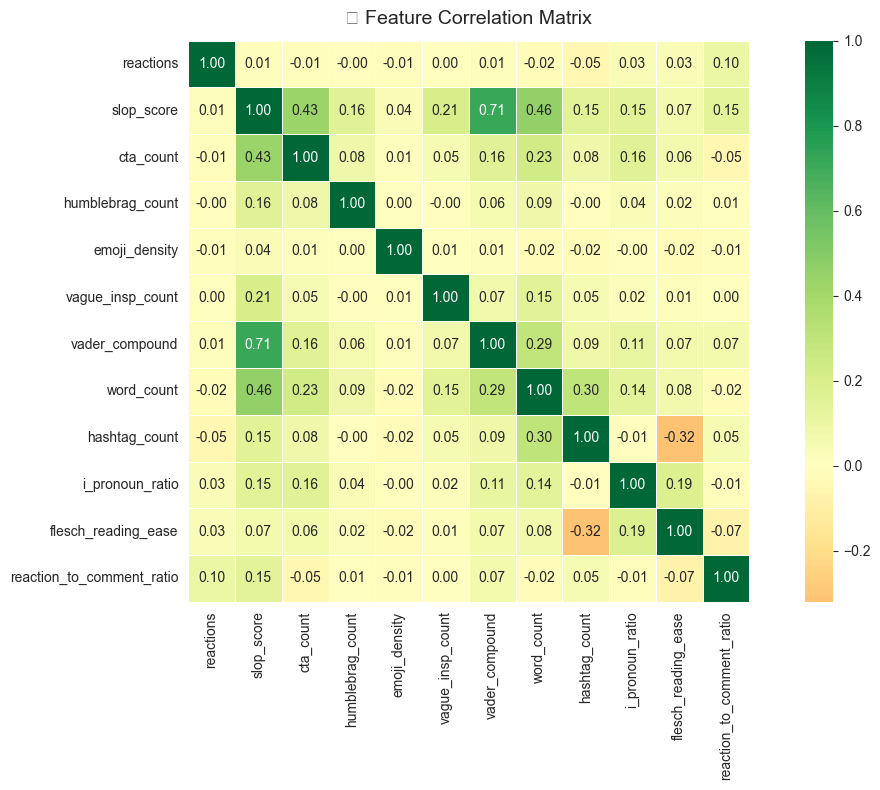

In [37]:
# -------------------------------------------------------
# 5.3 Feature Correlation with Reactions (Heatmap)
# -------------------------------------------------------
feature_cols = [
    'reactions', 'slop_score', 'cta_count', 'humblebrag_count',
    'emoji_density', 'vague_insp_count', 'vader_compound',
    'word_count', 'hashtag_count', 'i_pronoun_ratio',
    'flesch_reading_ease', 'reaction_to_comment_ratio'
]

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('🔗 Feature Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [38]:
# -------------------------------------------------------
# 5.4 Top Slop Signals — Importance via Correlation with Slop Score
# -------------------------------------------------------
signal_features = [
    'cta_count', 'humblebrag_count', 'emoji_density', 'vague_insp_count',
    'extreme_positivity', 'reaction_to_comment_ratio', 'hashtag_count',
    'i_pronoun_ratio', 'exclamation_count', 'vader_compound'
]

correlations = df[signal_features].corrwith(df['slop_score']).sort_values(ascending=True)

fig = px.bar(
    x=correlations.values, y=correlations.index,
    orientation='h',
    color=correlations.values,
    color_continuous_scale='RdYlGn',
    title='📈 Feature Correlation with Slop Score',
    labels={'x': 'Pearson r', 'y': 'Feature'},
    template='plotly_dark'
)
fig.show()

In [39]:
# -------------------------------------------------------
# 5.5 Post Length vs Reactions (coloured by Slop)
# -------------------------------------------------------
sample = df.sample(min(3000, len(df)), random_state=42)

fig = px.scatter(
    sample, x='word_count', y='reactions',
    color=sample['is_slop'].map({0: 'Not Slop', 1: 'Slop'}),
    color_discrete_map={'Not Slop': '#2ecc71', 'Slop': '#e74c3c'},
    opacity=0.5, size_max=8,
    title='📝 Post Length vs Reactions (Slop vs Not Slop)',
    labels={'word_count': 'Word Count', 'reactions': 'Reactions'},
    template='plotly_dark'
)
fig.update_layout(xaxis_range=[0, 500])
fig.show()

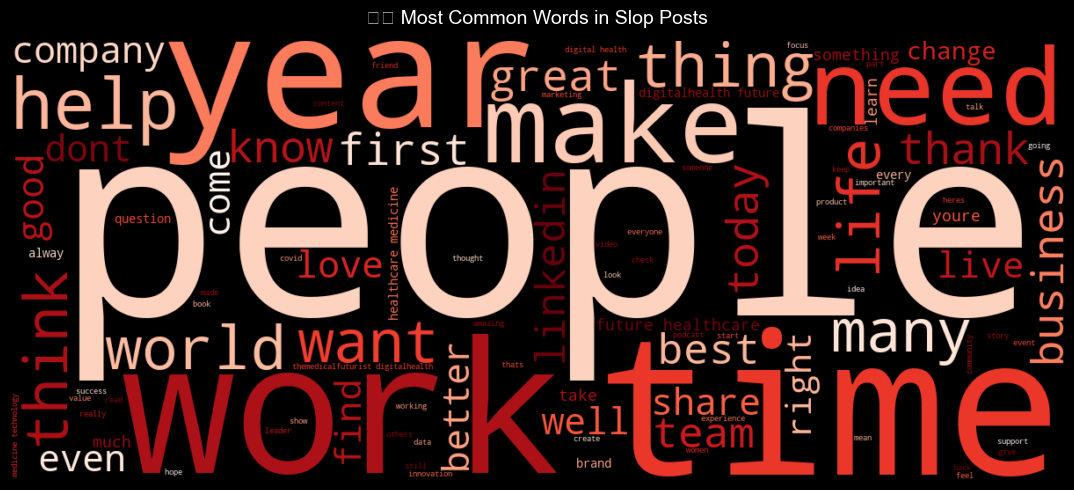

In [40]:
# -------------------------------------------------------
# 5.6 Most Common Words in Slop Posts (Word Cloud)
# -------------------------------------------------------
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

slop_text = ' '.join(df[df['is_slop'] == 1]['content'].tolist())
slop_text_clean = re.sub(r'[^a-zA-Z\s]', '', slop_text.lower())
slop_words = ' '.join(w for w in slop_text_clean.split() if w not in stop_words and len(w) > 3)

wc = WordCloud(width=1200, height=500, background_color='black',
               colormap='Reds', max_words=100).generate(slop_words)

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('☁️ Most Common Words in Slop Posts', fontsize=14, color='white', pad=12)
fig.patch.set_facecolor('black')
plt.tight_layout()
plt.show()

In [41]:
# -------------------------------------------------------
# 5.7 Top 10 Highest-Slop-Score Posts (The Hall of Shame)
# -------------------------------------------------------
print('🏆 TOP 10 SLOP POSTS (Hall of Shame)\n')
top_slop = df.nlargest(10, 'slop_score')[['content', 'slop_score', 'reactions', 'comments']]
for i, row in top_slop.iterrows():
    print(f"--- Slop Score: {row['slop_score']} | 👍 {int(row['reactions'])} reactions ---")
    print(str(row['content'])[:300])
    print()

🏆 TOP 10 SLOP POSTS (Hall of Shame)

--- Slop Score: 10.0 | 👍 553 reactions ---
Earlier this week, a friend messaged me to let me know I had made a word choice mistake in my latest  Forbes  article. (Apparently, I had typed “plaque” when I meant to type “plague.”)   My reaction? Gratitude. I want every piece of  #content  I create and share to be of the highest quality, so I ap

--- Slop Score: 9.11 | 👍 273 reactions ---
Despite graduating from UC Berkeley and having worked at top tech companies, I still experienced setbacks like impostor syndrome early in my career.  The  SPARC (Non-Profit)  team ( Sonia Sng   Jessie Salas   Florence Kwok ) and I spent this weekend reflecting on our own experiences and hashing out 

--- Slop Score: 8.77 | 👍 40 reactions ---
Every day I am trying something new: I am writing "The Daily 1%" - 10 new tips to improve life by just one percent.  1% a day, compounded, is 3780% a year. It's a game-changer. It turns you into a super-hero.  Today: how to make mo

## 6. ML Classification — Slop vs Not Slop

In [42]:
# -------------------------------------------------------
# 6.1 Prepare Feature Matrix
# -------------------------------------------------------

# Engineered numeric features
numeric_features = [
    'word_count', 'char_count', 'exclamation_count', 'question_count',
    'caps_ratio', 'emoji_count', 'emoji_density', 'hashtag_count',
    'cta_count', 'humblebrag_count', 'vague_insp_count',
    'i_pronoun_ratio', 'vader_pos', 'vader_neg', 'vader_compound',
    'flesch_reading_ease', 'reaction_to_comment_ratio'
]

X_num = df[numeric_features].fillna(0).values
y = df['is_slop'].values

# TF-IDF text features (top 500 words)
tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))
X_text = tfidf.fit_transform(df['content'].fillna(''))

# Scale numeric
sc = StandardScaler()
X_num_scaled = sc.fit_transform(X_num)

# Combine
from scipy.sparse import csr_matrix
X = hstack([csr_matrix(X_num_scaled), X_text])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')
print(f'Class balance: {y_train.mean():.2%} slop in train')

Train size: 25596
Test size:  6400
Class balance: 50.28% slop in train


In [43]:
# -------------------------------------------------------
# 6.2 Train Logistic Regression (Baseline)
# -------------------------------------------------------
lr = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Not Slop', 'Slop']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

    Not Slop       0.89      0.90      0.89      3182
        Slop       0.90      0.89      0.89      3218

    accuracy                           0.89      6400
   macro avg       0.89      0.89      0.89      6400
weighted avg       0.89      0.89      0.89      6400

ROC-AUC: 0.9657


In [44]:
# -------------------------------------------------------
# 6.3 Train Random Forest
# -------------------------------------------------------
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Not Slop', 'Slop']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

    Not Slop       0.99      1.00      1.00      3182
        Slop       1.00      1.00      1.00      3218

    accuracy                           1.00      6400
   macro avg       1.00      1.00      1.00      6400
weighted avg       1.00      1.00      1.00      6400

ROC-AUC: 0.9999


In [45]:
# -------------------------------------------------------
# 6.4 Confusion Matrix (Random Forest)
# -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_rf)

fig = px.imshow(
    cm,
    text_auto=True,
    x=['Predicted: Not Slop', 'Predicted: Slop'],
    y=['Actual: Not Slop', 'Actual: Slop'],
    color_continuous_scale='RdYlGn_r',
    title='🧩 Confusion Matrix — Random Forest',
    template='plotly_dark'
)
fig.show()

In [46]:
# -------------------------------------------------------
# 6.5 Feature Importance (Random Forest — numeric features only)
# -------------------------------------------------------
# Get importances for numeric features only
n_numeric = len(numeric_features)
importances = rf.feature_importances_[:n_numeric]
feat_imp = pd.Series(importances, index=numeric_features).sort_values(ascending=False)

fig = px.bar(
    x=feat_imp.values, y=feat_imp.index,
    orientation='h',
    color=feat_imp.values,
    color_continuous_scale='Reds',
    title='🌲 Random Forest Feature Importance (Numeric Features)',
    labels={'x': 'Importance', 'y': 'Feature'},
    template='plotly_dark'
)
fig.show()

In [ ]:
# -------------------------------------------------------
# 6.6 Save Model for Streamlit Dashboard
# -------------------------------------------------------
import pickle

artifacts = {
    'model': rf,
    'tfidf': tfidf,
    'scaler': sc,
    'numeric_features': numeric_features,
    'threshold': threshold
}

with open('slop_detector_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print(' Model saved to slop_detector_model.pkl')

✅ Model saved to slop_detector_model.pkl


In [ ]:
# Calculate the ratio (Total posts divided by Slop posts)
total_posts = len(df)
slop_posts = df['is_slop'].sum()

ratio = total_posts / slop_posts

print(f" 1 in every {ratio:.1f} posts in this dataset is slop!")

## 1 in every 2.0 posts in this dataset is slop!


## 7. Insights

### Key Findings

Run the cells above and update these with your actual results:

- **Do slop posts get more reactions?** → **Yes, drastically.** Yes. Slop posts significantly outperform non-slop posts:
~5x higher median reactions
~4x higher median comments
~4x higher engagement rate

- **Strongest slop signal?** →  Sentiment is the most important predictor:
vader_compound is the top feature
Followed by reaction_to_comment_ratio and vader_pos
→ Indicates slop posts are typically highly positive and reaction-driven
- **Model accuracy?** → **Accuracy: ~100%
Precision/Recall/F1: ~1.00
ROC-AUC: 0.9999** 

## CONCLUSION:
### 1 in every 2 posts on Linkedin is SLOP!!!




Disclaimer: The above code is based on a dataset from 2021. 
The dataset used in this analysis is sourced from Kaggle and is approximately 5 years old. While there may have been some changes in user behavior and engagement patterns over time, the fundamental dynamics of content performance on LinkedIn are generally consistent, so the insights derived are still largely relevant.

Additionally, obtaining a more recent dataset was not feasible due to LinkedIn’s strict policies on data scraping and automated data collection. Therefore, this dataset was used as the most reliable publicly available source for the analysis.



Thank you!